In [18]:
# ============================================================================
# CELL 1: ENVIRONMENT SETUP + ALL IMPORTS
# ============================================================================
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'  # reduces OOM fragmentation

import json, random, math, time, copy, glob, gc
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import functional as TF

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_recall_fscore_support
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from PIL import Image
import cv2

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
else:
    print("WARNING: CUDA not available — training will be very slow.")

def free_memory(*objs):
    for o in objs:
        del o
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

PyTorch version: 2.9.0+cu128
Torchvision version: 0.24.0+cu128
Using device: cuda
GPU: NVIDIA GeForce RTX 3060
GPU memory: 11.62 GB


In [19]:
# ============================================================================
# CELL 0: GPU MEMORY DIAGNOSTIC + CLEANUP
# Run this before any training cell, especially after re-running earlier cells
# (final model training, ablation, baselines, quantization) in the same session.
# ============================================================================
import subprocess, gc

def show_gpu_memory():
    if DEVICE.type != "cuda":
        print("No CUDA device.")
        return
    print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GiB")
    print(f"Reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GiB")
    try:
        out = subprocess.check_output(['nvidia-smi', '--query-gpu=memory.used,memory.total',
                                        '--format=csv,noheader,nounits']).decode()
        used, total = out.strip().split(',')
        print(f"nvidia-smi: {used.strip()} MiB used / {total.strip()} MiB total (ALL processes on this GPU)")
    except Exception as e:
        print("nvidia-smi not available:", e)

print("=== BEFORE cleanup ===")
show_gpu_memory()

# Delete known large globals from earlier cells if they exist in this session
_candidates = ['final_model_trashnet', 'final_model_taco', 'model', 'model_cpu',
               'quantized_model', 'ablation_trashnet']
for name in _candidates:
    if name in globals():
        try:
            obj = globals()[name]
            if hasattr(obj, 'to'):
                obj.to('cpu')
            del globals()[name]
            print(f"Deleted global: {name}")
        except Exception:
            pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print("\n=== AFTER cleanup ===")
show_gpu_memory()

print("\nIf 'nvidia-smi' still shows most memory used by OTHER processes, "
      "you likely have another Python/Jupyter kernel or process holding the GPU. "
      "Run `nvidia-smi` in a terminal to identify the PID and stop that kernel/process, "
      "or restart this notebook's kernel entirely (not just re-run cells).")

=== BEFORE cleanup ===
Allocated: 0.90 GiB
Reserved:  7.97 GiB
nvidia-smi: 8717 MiB used / 12288 MiB total (ALL processes on this GPU)
Deleted global: model

=== AFTER cleanup ===
Allocated: 0.84 GiB
Reserved:  0.94 GiB
nvidia-smi: 1517 MiB used / 12288 MiB total (ALL processes on this GPU)

If 'nvidia-smi' still shows most memory used by OTHER processes, you likely have another Python/Jupyter kernel or process holding the GPU. Run `nvidia-smi` in a terminal to identify the PID and stop that kernel/process, or restart this notebook's kernel entirely (not just re-run cells).


In [20]:
show_gpu_memory()

Allocated: 0.84 GiB
Reserved:  0.94 GiB
nvidia-smi: 1517 MiB used / 12288 MiB total (ALL processes on this GPU)


In [21]:
# ============================================================================
# CELL 2: LOCAL PATHS (NO GOOGLE DRIVE)
# ============================================================================
HOME_DIR = Path.home()
DATASETS_ROOT = HOME_DIR / 'Desktop' / 'waste'

TACO_DIR = DATASETS_ROOT / "TACO"
TRASHNET_DIR = DATASETS_ROOT / "Trashnet"
TRASHNET_AUG_DIR = DATASETS_ROOT / "Trashnet_augmented"   # created by Cell 6

OUTPUT_DIR = Path.cwd() / 'ResSeMo_Results'
for sub in ['checkpoints', 'results', 'results/cv_folds', 'checkpoints/cv_folds',
            'plots', 'logs']:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

print(f"Datasets root: {DATASETS_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

if TACO_DIR.exists():
    print(f"✓ TACO found at: {TACO_DIR}")
else:
    print(f"✗ TACO not found at: {TACO_DIR}")

if TRASHNET_DIR.exists():
    print(f"✓ TrashNet found at: {TRASHNET_DIR}")
else:
    print(f"✗ TrashNet not found at: {TRASHNET_DIR}")

CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
print("Class mapping:", CLASS_TO_IDX)

Datasets root: /home/nasc/Desktop/waste
Output directory: /home/nasc/Desktop/waste/ResSeMo_Results
✓ TACO found at: /home/nasc/Desktop/waste/TACO
✓ TrashNet found at: /home/nasc/Desktop/waste/Trashnet
Class mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [22]:
# ============================================================================
# CELL 3: TACO FINE-GRAINED CATEGORY -> 6-CLASS TRASHNET MAPPING
# ============================================================================
# ASSUMPTION: paper gives only one example mapping (plastic sub-categories -> Plastic).
# Full mapping below is a reasonable construction, not the authors' exact table.

TACO_TO_TRASHNET = {
    # ---- Plastic ----
    'Plastic bottle': 'plastic', 'Plastic bottle cap': 'plastic', 'Clear plastic bottle': 'plastic',
    'Other plastic bottle': 'plastic', 'Plastic bag - wrapper': 'plastic', 'Plastic film': 'plastic',
    'Plastic container': 'plastic', 'Plastic gloves': 'plastic', 'Plastic utensils': 'plastic',
    'Plastic straw': 'plastic', 'Six pack rings': 'plastic', 'Single-use carrier bag': 'plastic',
    'Polypropylene bag': 'plastic', 'Crisp packet': 'plastic', 'Spread tub': 'plastic',
    'Tupperware': 'plastic', 'Disposable food container': 'plastic', 'Foam food container': 'plastic',
    'Other plastic wrapper': 'plastic', 'Other plastic': 'plastic', 'Other plastic container': 'plastic',
    'Plastic lid': 'plastic', 'Squeezable tube': 'plastic', 'Disposable plastic cup': 'plastic',
    'Foam cup': 'plastic', 'Garbage bag': 'plastic', 'Styrofoam piece': 'plastic',
    # ---- Paper ----
    'Magazine paper': 'paper', 'Tissues': 'paper', 'Wrapping paper': 'paper', 'Normal paper': 'paper',
    'Paper bag': 'paper', 'Paper cup': 'paper', 'Napkin': 'paper', 'Toilet tube': 'paper',
    'Other paper': 'paper',
    # ---- Cardboard ----
    'Corrugated carton': 'cardboard', 'Drink carton': 'cardboard', 'Egg carton': 'cardboard',
    'Meal carton': 'cardboard', 'Pizza box': 'cardboard', 'Other carton': 'cardboard',
    'Cardboard': 'cardboard',
    # ---- Glass ----
    'Glass bottle': 'glass', 'Broken glass': 'glass', 'Glass cup': 'glass', 'Glass jar': 'glass',
    # ---- Metal ----
    'Aluminium foil': 'metal', 'Metal bottle cap': 'metal', 'Aluminium blister pack': 'metal',
    'Carded blister pack': 'metal', 'Battery': 'metal', 'Metal lid': 'metal', 'Food Can': 'metal',
    'Aerosol': 'metal', 'Drink can': 'metal', 'Pop tab': 'metal', 'Scrap metal': 'metal',
    'Other metal container': 'metal',
    # ---- Trash ----
    'Cigarette': 'trash', 'Unlabeled litter': 'trash', 'Rope & strings': 'trash', 'Shoe': 'trash',
    'Rope': 'trash', 'Plastic straw wrapper': 'trash',
}

TACO_EXCLUDE = {'Construction waste', 'Industrial waste'}

def map_taco_category(cat_name):
    if cat_name in TACO_EXCLUDE:
        return None
    return TACO_TO_TRASHNET.get(cat_name, None)

print(f"{len(TACO_TO_TRASHNET)} TACO categories mapped -> {NUM_CLASSES} classes.")

65 TACO categories mapped -> 6 classes.


In [23]:
# ============================================================================
# CELL 4: BUILD TRASHNET FILE INDEX
# ============================================================================
def build_trashnet_index(trashnet_dir):
    records = []
    for cls in CLASSES:
        cls_dir = os.path.join(trashnet_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"WARNING: class folder missing for '{cls}' at {cls_dir}")
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({
                    'path': os.path.join(cls_dir, fname),
                    'label': CLASS_TO_IDX[cls],
                    'class_name': cls,
                    'bbox': None,
                    'source': 'trashnet'
                })
    return pd.DataFrame(records)

trashnet_df_raw = build_trashnet_index(TRASHNET_DIR)
print("TrashNet raw samples:", len(trashnet_df_raw))
if len(trashnet_df_raw):
    print(trashnet_df_raw['class_name'].value_counts())

TrashNet raw samples: 2527
class_name
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64


In [39]:
# ============================================================================
# CELL 5 (FIXED): BUILD TACO FILE INDEX WITH CATEGORY MAPPING + BBOX ENLARGEMENT
# ============================================================================
TACO_ANN_JSON = TACO_DIR / "annotations.json"
if not TACO_ANN_JSON.is_file():
    json_files = list(TACO_DIR.rglob("*.json"))
    matches = [f for f in json_files if f.name.lower() == "annotations.json"
               and f.parent.name == "data"]  # prefer the master annotations.json in .../data/, not per-batch ones
    if not matches:
        matches = [f for f in json_files if f.name.lower() == "annotations.json"]
    TACO_ANN_JSON = matches[0] if matches else None
    if TACO_ANN_JSON is None:
        print("⚠ annotations.json not found anywhere under TACO_DIR.")

# ---- FIX: the actual image root is the FOLDER CONTAINING annotations.json,
# not TACO_DIR itself. file_name entries like "batch_1/000006.jpg" are relative
# to this folder (.../TACO/TACO/data/), not the outer TACO_DIR.
TACO_IMAGE_ROOT = TACO_ANN_JSON.parent if TACO_ANN_JSON is not None else TACO_DIR
print(f"TACO_ANN_JSON: {TACO_ANN_JSON}")
print(f"TACO_IMAGE_ROOT (derived): {TACO_IMAGE_ROOT}")

# ---- Add the 5 previously-unmapped categories found in your annotations.json ----
TACO_TO_TRASHNET.update({
    'Food waste': 'trash',
    'Other plastic cup': 'plastic',
    'Paper straw': 'paper',
    'Plastic glooves': 'plastic',       # note: matches the typo as it appears in the actual file
    'Plastified paper bag': 'paper',
})

def build_taco_index(ann_json, taco_image_root):
    if ann_json is None or not os.path.isfile(ann_json):
        print("TACO annotations.json not found — skipping TACO indexing.")
        return pd.DataFrame(columns=['path','label','class_name','bbox','img_w','img_h','source'])

    print(f"Using TACO annotations: {ann_json}")
    print(f"Resolving images relative to: {taco_image_root}")
    with open(ann_json, 'r') as f:
        coco = json.load(f)

    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}
    img_id_to_info = {im['id']: im for im in coco['images']}

    records = []
    n_dropped_unmapped, n_dropped_missing_file = 0, 0

    for ann in coco['annotations']:
        cat_name = cat_id_to_name.get(ann['category_id'])
        mapped = map_taco_category(cat_name)
        if mapped is None:
            n_dropped_unmapped += 1
            continue
        img_info = img_id_to_info.get(ann['image_id'])
        if img_info is None:
            continue

        file_name = img_info['file_name']
        img_path = os.path.join(taco_image_root, file_name)  # FIXED: use taco_image_root, not TACO_DIR
        if not os.path.isfile(img_path):
            alt = os.path.join(taco_image_root, "images", os.path.basename(file_name))
            img_path = alt if os.path.isfile(alt) else None
        if img_path is None:
            n_dropped_missing_file += 1
            continue

        x, y, w, h = ann['bbox']
        pad_w, pad_h = w * 0.10, h * 0.10
        x_new = max(0, x - pad_w / 2)
        y_new = max(0, y - pad_h / 2)
        w_new = w + pad_w
        h_new = h + pad_h

        records.append({
            'path': img_path,
            'label': CLASS_TO_IDX[mapped],
            'class_name': mapped,
            'bbox': [x_new, y_new, w_new, h_new],
            'img_w': img_info['width'],
            'img_h': img_info['height'],
            'source': 'taco'
        })

    print(f"Dropped (unmapped category): {n_dropped_unmapped}")
    print(f"Dropped (image file not found): {n_dropped_missing_file}")
    return pd.DataFrame(records)

taco_df = build_taco_index(TACO_ANN_JSON, TACO_IMAGE_ROOT)
print("\nTACO samples (after mapping/cleaning):", len(taco_df))
if len(taco_df):
    print(taco_df['class_name'].value_counts())# ============================================================================
# CELL 5 (FIXED): BUILD TACO FILE INDEX WITH CATEGORY MAPPING + BBOX ENLARGEMENT
# ============================================================================
TACO_ANN_JSON = TACO_DIR / "annotations.json"
if not TACO_ANN_JSON.is_file():
    json_files = list(TACO_DIR.rglob("*.json"))
    matches = [f for f in json_files if f.name.lower() == "annotations.json"
               and f.parent.name == "data"]  # prefer the master annotations.json in .../data/, not per-batch ones
    if not matches:
        matches = [f for f in json_files if f.name.lower() == "annotations.json"]
    TACO_ANN_JSON = matches[0] if matches else None
    if TACO_ANN_JSON is None:
        print("⚠ annotations.json not found anywhere under TACO_DIR.")

# ---- FIX: the actual image root is the FOLDER CONTAINING annotations.json,
# not TACO_DIR itself. file_name entries like "batch_1/000006.jpg" are relative
# to this folder (.../TACO/TACO/data/), not the outer TACO_DIR.
TACO_IMAGE_ROOT = TACO_ANN_JSON.parent if TACO_ANN_JSON is not None else TACO_DIR
print(f"TACO_ANN_JSON: {TACO_ANN_JSON}")
print(f"TACO_IMAGE_ROOT (derived): {TACO_IMAGE_ROOT}")

# ---- Add the 5 previously-unmapped categories found in your annotations.json ----
TACO_TO_TRASHNET.update({
    'Food waste': 'trash',
    'Other plastic cup': 'plastic',
    'Paper straw': 'paper',
    'Plastic glooves': 'plastic',       # note: matches the typo as it appears in the actual file
    'Plastified paper bag': 'paper',
})

def build_taco_index(ann_json, taco_image_root):
    if ann_json is None or not os.path.isfile(ann_json):
        print("TACO annotations.json not found — skipping TACO indexing.")
        return pd.DataFrame(columns=['path','label','class_name','bbox','img_w','img_h','source'])

    print(f"Using TACO annotations: {ann_json}")
    print(f"Resolving images relative to: {taco_image_root}")
    with open(ann_json, 'r') as f:
        coco = json.load(f)

    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}
    img_id_to_info = {im['id']: im for im in coco['images']}

    records = []
    n_dropped_unmapped, n_dropped_missing_file = 0, 0

    for ann in coco['annotations']:
        cat_name = cat_id_to_name.get(ann['category_id'])
        mapped = map_taco_category(cat_name)
        if mapped is None:
            n_dropped_unmapped += 1
            continue
        img_info = img_id_to_info.get(ann['image_id'])
        if img_info is None:
            continue

        file_name = img_info['file_name']
        img_path = os.path.join(taco_image_root, file_name)  # FIXED: use taco_image_root, not TACO_DIR
        if not os.path.isfile(img_path):
            alt = os.path.join(taco_image_root, "images", os.path.basename(file_name))
            img_path = alt if os.path.isfile(alt) else None
        if img_path is None:
            n_dropped_missing_file += 1
            continue

        x, y, w, h = ann['bbox']
        pad_w, pad_h = w * 0.10, h * 0.10
        x_new = max(0, x - pad_w / 2)
        y_new = max(0, y - pad_h / 2)
        w_new = w + pad_w
        h_new = h + pad_h

        records.append({
            'path': img_path,
            'label': CLASS_TO_IDX[mapped],
            'class_name': mapped,
            'bbox': [x_new, y_new, w_new, h_new],
            'img_w': img_info['width'],
            'img_h': img_info['height'],
            'source': 'taco'
        })

    print(f"Dropped (unmapped category): {n_dropped_unmapped}")
    print(f"Dropped (image file not found): {n_dropped_missing_file}")
    return pd.DataFrame(records)

taco_df = build_taco_index(TACO_ANN_JSON, TACO_IMAGE_ROOT)
print("\nTACO samples (after mapping/cleaning):", len(taco_df))
if len(taco_df):
    print(taco_df['class_name'].value_counts())# ============================================================================
# CELL 5 (FIXED): BUILD TACO FILE INDEX WITH CATEGORY MAPPING + BBOX ENLARGEMENT
# ============================================================================
TACO_ANN_JSON = TACO_DIR / "annotations.json"
if not TACO_ANN_JSON.is_file():
    json_files = list(TACO_DIR.rglob("*.json"))
    matches = [f for f in json_files if f.name.lower() == "annotations.json"
               and f.parent.name == "data"]  # prefer the master annotations.json in .../data/, not per-batch ones
    if not matches:
        matches = [f for f in json_files if f.name.lower() == "annotations.json"]
    TACO_ANN_JSON = matches[0] if matches else None
    if TACO_ANN_JSON is None:
        print("⚠ annotations.json not found anywhere under TACO_DIR.")

# ---- FIX: the actual image root is the FOLDER CONTAINING annotations.json,
# not TACO_DIR itself. file_name entries like "batch_1/000006.jpg" are relative
# to this folder (.../TACO/TACO/data/), not the outer TACO_DIR.
TACO_IMAGE_ROOT = TACO_ANN_JSON.parent if TACO_ANN_JSON is not None else TACO_DIR
print(f"TACO_ANN_JSON: {TACO_ANN_JSON}")
print(f"TACO_IMAGE_ROOT (derived): {TACO_IMAGE_ROOT}")

# ---- Add the 5 previously-unmapped categories found in your annotations.json ----
TACO_TO_TRASHNET.update({
    'Food waste': 'trash',
    'Other plastic cup': 'plastic',
    'Paper straw': 'paper',
    'Plastic glooves': 'plastic',       # note: matches the typo as it appears in the actual file
    'Plastified paper bag': 'paper',
})

def build_taco_index(ann_json, taco_image_root):
    if ann_json is None or not os.path.isfile(ann_json):
        print("TACO annotations.json not found — skipping TACO indexing.")
        return pd.DataFrame(columns=['path','label','class_name','bbox','img_w','img_h','source'])

    print(f"Using TACO annotations: {ann_json}")
    print(f"Resolving images relative to: {taco_image_root}")
    with open(ann_json, 'r') as f:
        coco = json.load(f)

    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}
    img_id_to_info = {im['id']: im for im in coco['images']}

    records = []
    n_dropped_unmapped, n_dropped_missing_file = 0, 0

    for ann in coco['annotations']:
        cat_name = cat_id_to_name.get(ann['category_id'])
        mapped = map_taco_category(cat_name)
        if mapped is None:
            n_dropped_unmapped += 1
            continue
        img_info = img_id_to_info.get(ann['image_id'])
        if img_info is None:
            continue

        file_name = img_info['file_name']
        img_path = os.path.join(taco_image_root, file_name)  # FIXED: use taco_image_root, not TACO_DIR
        if not os.path.isfile(img_path):
            alt = os.path.join(taco_image_root, "images", os.path.basename(file_name))
            img_path = alt if os.path.isfile(alt) else None
        if img_path is None:
            n_dropped_missing_file += 1
            continue

        x, y, w, h = ann['bbox']
        pad_w, pad_h = w * 0.10, h * 0.10
        x_new = max(0, x - pad_w / 2)
        y_new = max(0, y - pad_h / 2)
        w_new = w + pad_w
        h_new = h + pad_h

        records.append({
            'path': img_path,
            'label': CLASS_TO_IDX[mapped],
            'class_name': mapped,
            'bbox': [x_new, y_new, w_new, h_new],
            'img_w': img_info['width'],
            'img_h': img_info['height'],
            'source': 'taco'
        })

    print(f"Dropped (unmapped category): {n_dropped_unmapped}")
    print(f"Dropped (image file not found): {n_dropped_missing_file}")
    return pd.DataFrame(records)

taco_df = build_taco_index(TACO_ANN_JSON, TACO_IMAGE_ROOT)
print("\nTACO samples (after mapping/cleaning):", len(taco_df))
if len(taco_df):
    print(taco_df['class_name'].value_counts())# ============================================================================
# CELL 5 (FIXED): BUILD TACO FILE INDEX WITH CATEGORY MAPPING + BBOX ENLARGEMENT
# ============================================================================
TACO_ANN_JSON = TACO_DIR / "annotations.json"
if not TACO_ANN_JSON.is_file():
    json_files = list(TACO_DIR.rglob("*.json"))
    matches = [f for f in json_files if f.name.lower() == "annotations.json"
               and f.parent.name == "data"]  # prefer the master annotations.json in .../data/, not per-batch ones
    if not matches:
        matches = [f for f in json_files if f.name.lower() == "annotations.json"]
    TACO_ANN_JSON = matches[0] if matches else None
    if TACO_ANN_JSON is None:
        print("⚠ annotations.json not found anywhere under TACO_DIR.")

# ---- FIX: the actual image root is the FOLDER CONTAINING annotations.json,
# not TACO_DIR itself. file_name entries like "batch_1/000006.jpg" are relative
# to this folder (.../TACO/TACO/data/), not the outer TACO_DIR.
TACO_IMAGE_ROOT = TACO_ANN_JSON.parent if TACO_ANN_JSON is not None else TACO_DIR
print(f"TACO_ANN_JSON: {TACO_ANN_JSON}")
print(f"TACO_IMAGE_ROOT (derived): {TACO_IMAGE_ROOT}")

# ---- Add the 5 previously-unmapped categories found in your annotations.json ----
TACO_TO_TRASHNET.update({
    'Food waste': 'trash',
    'Other plastic cup': 'plastic',
    'Paper straw': 'paper',
    'Plastic glooves': 'plastic',       # note: matches the typo as it appears in the actual file
    'Plastified paper bag': 'paper',
})

def build_taco_index(ann_json, taco_image_root):
    if ann_json is None or not os.path.isfile(ann_json):
        print("TACO annotations.json not found — skipping TACO indexing.")
        return pd.DataFrame(columns=['path','label','class_name','bbox','img_w','img_h','source'])

    print(f"Using TACO annotations: {ann_json}")
    print(f"Resolving images relative to: {taco_image_root}")
    with open(ann_json, 'r') as f:
        coco = json.load(f)

    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}
    img_id_to_info = {im['id']: im for im in coco['images']}

    records = []
    n_dropped_unmapped, n_dropped_missing_file = 0, 0

    for ann in coco['annotations']:
        cat_name = cat_id_to_name.get(ann['category_id'])
        mapped = map_taco_category(cat_name)
        if mapped is None:
            n_dropped_unmapped += 1
            continue
        img_info = img_id_to_info.get(ann['image_id'])
        if img_info is None:
            continue

        file_name = img_info['file_name']
        img_path = os.path.join(taco_image_root, file_name)  # FIXED: use taco_image_root, not TACO_DIR
        if not os.path.isfile(img_path):
            alt = os.path.join(taco_image_root, "images", os.path.basename(file_name))
            img_path = alt if os.path.isfile(alt) else None
        if img_path is None:
            n_dropped_missing_file += 1
            continue

        x, y, w, h = ann['bbox']
        pad_w, pad_h = w * 0.10, h * 0.10
        x_new = max(0, x - pad_w / 2)
        y_new = max(0, y - pad_h / 2)
        w_new = w + pad_w
        h_new = h + pad_h

        records.append({
            'path': img_path,
            'label': CLASS_TO_IDX[mapped],
            'class_name': mapped,
            'bbox': [x_new, y_new, w_new, h_new],
            'img_w': img_info['width'],
            'img_h': img_info['height'],
            'source': 'taco'
        })

    print(f"Dropped (unmapped category): {n_dropped_unmapped}")
    print(f"Dropped (image file not found): {n_dropped_missing_file}")
    return pd.DataFrame(records)

taco_df = build_taco_index(TACO_ANN_JSON, TACO_IMAGE_ROOT)
print("\nTACO samples (after mapping/cleaning):", len(taco_df))
if len(taco_df):
    print(taco_df['class_name'].value_counts())# ============================================================================
# CELL 5 (FIXED): BUILD TACO FILE INDEX WITH CATEGORY MAPPING + BBOX ENLARGEMENT
# ============================================================================
TACO_ANN_JSON = TACO_DIR / "annotations.json"
if not TACO_ANN_JSON.is_file():
    json_files = list(TACO_DIR.rglob("*.json"))
    matches = [f for f in json_files if f.name.lower() == "annotations.json"
               and f.parent.name == "data"]  # prefer the master annotations.json in .../data/, not per-batch ones
    if not matches:
        matches = [f for f in json_files if f.name.lower() == "annotations.json"]
    TACO_ANN_JSON = matches[0] if matches else None
    if TACO_ANN_JSON is None:
        print("⚠ annotations.json not found anywhere under TACO_DIR.")

# ---- FIX: the actual image root is the FOLDER CONTAINING annotations.json,
# not TACO_DIR itself. file_name entries like "batch_1/000006.jpg" are relative
# to this folder (.../TACO/TACO/data/), not the outer TACO_DIR.
TACO_IMAGE_ROOT = TACO_ANN_JSON.parent if TACO_ANN_JSON is not None else TACO_DIR
print(f"TACO_ANN_JSON: {TACO_ANN_JSON}")
print(f"TACO_IMAGE_ROOT (derived): {TACO_IMAGE_ROOT}")

# ---- Add the 5 previously-unmapped categories found in your annotations.json ----
TACO_TO_TRASHNET.update({
    'Food waste': 'trash',
    'Other plastic cup': 'plastic',
    'Paper straw': 'paper',
    'Plastic glooves': 'plastic',       # note: matches the typo as it appears in the actual file
    'Plastified paper bag': 'paper',
})

def build_taco_index(ann_json, taco_image_root):
    if ann_json is None or not os.path.isfile(ann_json):
        print("TACO annotations.json not found — skipping TACO indexing.")
        return pd.DataFrame(columns=['path','label','class_name','bbox','img_w','img_h','source'])

    print(f"Using TACO annotations: {ann_json}")
    print(f"Resolving images relative to: {taco_image_root}")
    with open(ann_json, 'r') as f:
        coco = json.load(f)

    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}
    img_id_to_info = {im['id']: im for im in coco['images']}

    records = []
    n_dropped_unmapped, n_dropped_missing_file = 0, 0

    for ann in coco['annotations']:
        cat_name = cat_id_to_name.get(ann['category_id'])
        mapped = map_taco_category(cat_name)
        if mapped is None:
            n_dropped_unmapped += 1
            continue
        img_info = img_id_to_info.get(ann['image_id'])
        if img_info is None:
            continue

        file_name = img_info['file_name']
        img_path = os.path.join(taco_image_root, file_name)  # FIXED: use taco_image_root, not TACO_DIR
        if not os.path.isfile(img_path):
            alt = os.path.join(taco_image_root, "images", os.path.basename(file_name))
            img_path = alt if os.path.isfile(alt) else None
        if img_path is None:
            n_dropped_missing_file += 1
            continue

        x, y, w, h = ann['bbox']
        pad_w, pad_h = w * 0.10, h * 0.10
        x_new = max(0, x - pad_w / 2)
        y_new = max(0, y - pad_h / 2)
        w_new = w + pad_w
        h_new = h + pad_h

        records.append({
            'path': img_path,
            'label': CLASS_TO_IDX[mapped],
            'class_name': mapped,
            'bbox': [x_new, y_new, w_new, h_new],
            'img_w': img_info['width'],
            'img_h': img_info['height'],
            'source': 'taco'
        })

    print(f"Dropped (unmapped category): {n_dropped_unmapped}")
    print(f"Dropped (image file not found): {n_dropped_missing_file}")
    return pd.DataFrame(records)

taco_df = build_taco_index(TACO_ANN_JSON, TACO_IMAGE_ROOT)
print("\nTACO samples (after mapping/cleaning):", len(taco_df))
if len(taco_df):
    print(taco_df['class_name'].value_counts())

TACO_ANN_JSON: /home/nasc/Desktop/waste/TACO/TACO/data/annotations.json
TACO_IMAGE_ROOT (derived): /home/nasc/Desktop/waste/TACO/TACO/data
Using TACO annotations: /home/nasc/Desktop/waste/TACO/TACO/data/annotations.json
Resolving images relative to: /home/nasc/Desktop/waste/TACO/TACO/data
Dropped (unmapped category): 0
Dropped (image file not found): 910

TACO samples (after mapping/cleaning): 3874
class_name
plastic      1803
trash         935
metal         508
glass         233
paper         211
cardboard     184
Name: count, dtype: int64
TACO_ANN_JSON: /home/nasc/Desktop/waste/TACO/TACO/data/annotations.json
TACO_IMAGE_ROOT (derived): /home/nasc/Desktop/waste/TACO/TACO/data
Using TACO annotations: /home/nasc/Desktop/waste/TACO/TACO/data/annotations.json
Resolving images relative to: /home/nasc/Desktop/waste/TACO/TACO/data
Dropped (unmapped category): 0
Dropped (image file not found): 910

TACO samples (after mapping/cleaning): 3874
class_name
plastic      1803
trash         935
meta

In [37]:
# ============================================================================
# CELL 5-DEBUG-A: LOCATE THE ANNOTATIONS FILE
# ============================================================================
print("TACO_DIR:", TACO_DIR)
print("TACO_DIR exists:", TACO_DIR.exists())

if TACO_DIR.exists():
    print("\nContents of TACO_DIR:")
    for item in sorted(TACO_DIR.iterdir()):
        print(" ", item.name, "(dir)" if item.is_dir() else "(file)")

print("\nTACO_ANN_JSON currently set to:", TACO_ANN_JSON)
print("TACO_ANN_JSON is file:", TACO_ANN_JSON.is_file() if TACO_ANN_JSON else "N/A (None)")

print("\nSearching recursively for .json files under TACO_DIR...")
json_files = list(TACO_DIR.rglob("*.json")) if TACO_DIR.exists() else []
if json_files:
    for f in json_files:
        size_kb = f.stat().st_size / 1024
        print(f"  {f}  ({size_kb:.1f} KB)")
else:
    print("  No .json files found anywhere under TACO_DIR.")

TACO_DIR: /home/nasc/Desktop/waste/TACO
TACO_DIR exists: True

Contents of TACO_DIR:
  TACO (dir)
  __MACOSX (dir)

TACO_ANN_JSON currently set to: /home/nasc/Desktop/waste/TACO/TACO/data/annotations.json
TACO_ANN_JSON is file: True

Searching recursively for .json files under TACO_DIR...
  /home/nasc/Desktop/waste/TACO/TACO/data/annotations.json  (2951.2 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_15/annotations.json  (167.2 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_7/annotations.json  (270.7 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_6/annotations.json  (224.9 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_3/annotations.json  (197.7 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_14/annotations.json  (161.0 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_1/annotations.json  (324.6 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_13/annotations.json  (192.5 KB)
  /home/nasc/Desktop/waste/TACO/TACO/data/batch_4/annotations.json  (144.5 KB)
  /

In [38]:
# ============================================================================
# CELL 5-DEBUG-B: INSPECT ANNOTATIONS CONTENT
# ============================================================================
if TACO_ANN_JSON is not None and TACO_ANN_JSON.is_file():
    with open(TACO_ANN_JSON, 'r') as f:
        coco = json.load(f)

    print("Number of categories in annotations.json:", len(coco['categories']))
    print("Number of images:", len(coco['images']))
    print("Number of annotations:", len(coco['annotations']))

    print("\nFirst 15 category names in the file:")
    for c in coco['categories'][:15]:
        print(" ", repr(c['name']))

    print("\nSample image file_name entries:")
    for im in coco['images'][:5]:
        print(" ", im['file_name'])

    all_cat_names = {c['name'] for c in coco['categories']}
    matched = all_cat_names & set(TACO_TO_TRASHNET.keys())
    unmatched = all_cat_names - set(TACO_TO_TRASHNET.keys())
    print(f"\n{len(matched)} / {len(all_cat_names)} category names matched our TACO_TO_TRASHNET mapping.")
    print("Unmatched category names:")
    for name in sorted(unmatched):
        print(" ", repr(name))

    sample_im = coco['images'][0]
    test_path1 = TACO_DIR / sample_im['file_name']
    test_path2 = TACO_DIR / "images" / os.path.basename(sample_im['file_name'])
    print(f"\nTesting first image path resolution:")
    print(f"  Path 1: {test_path1}  exists={test_path1.is_file()}")
    print(f"  Path 2: {test_path2}  exists={test_path2.is_file()}")
else:
    print("TACO_ANN_JSON is None or not a file — the problem is in Debug Cell A's output, fix that first.")

Number of categories in annotations.json: 60
Number of images: 1500
Number of annotations: 4784

First 15 category names in the file:
  'Aluminium foil'
  'Battery'
  'Aluminium blister pack'
  'Carded blister pack'
  'Other plastic bottle'
  'Clear plastic bottle'
  'Glass bottle'
  'Plastic bottle cap'
  'Metal bottle cap'
  'Broken glass'
  'Food Can'
  'Aerosol'
  'Drink can'
  'Toilet tube'
  'Other carton'

Sample image file_name entries:
  batch_1/000006.jpg
  batch_1/000008.jpg
  batch_1/000010.jpg
  batch_1/000019.jpg
  batch_1/000026.jpg

55 / 60 category names matched our TACO_TO_TRASHNET mapping.
Unmatched category names:
  'Food waste'
  'Other plastic cup'
  'Paper straw'
  'Plastic glooves'
  'Plastified paper bag'

Testing first image path resolution:
  Path 1: /home/nasc/Desktop/waste/TACO/batch_1/000006.jpg  exists=False
  Path 2: /home/nasc/Desktop/waste/TACO/images/000006.jpg  exists=False


In [25]:
# ============================================================================
# CELL 6: OFFLINE TRASHNET AUGMENTATION (paper's Methods-text spec, distinct from
# Table 2's live training-time augmentation): rotation 0-360°, crop ratio 0.8-1.0,
# brightness factor 0.5-1.5, expand each class to 800-1000 images.
# Skips classes that are already augmented (restart-friendly).
# ============================================================================
import shutil

TARGET_PER_CLASS = 900

def offline_augment_trashnet(trashnet_dir, out_dir, target_per_class=TARGET_PER_CLASS):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for cls in CLASSES:
        src_dir = Path(trashnet_dir) / cls
        dst_dir = out_dir / cls
        dst_dir.mkdir(parents=True, exist_ok=True)

        existing_dst = list(dst_dir.glob('*'))
        if len(existing_dst) >= target_per_class:
            print(f"[SKIP] {cls}: already has {len(existing_dst)} images (>= target).")
            continue

        if not src_dir.is_dir():
            print(f"WARNING: source folder missing for '{cls}'")
            continue

        files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # copy originals if not already copied
        for f in files:
            dst_f = dst_dir / f
            if not dst_f.exists():
                shutil.copy(src_dir / f, dst_f)

        n_existing = len(list(dst_dir.glob('*')))
        n_needed = max(0, target_per_class - n_existing)
        print(f"{cls}: {n_existing} present, generating {n_needed} more augmented copies")

        i = 0
        while i < n_needed:
            src_file = random.choice(files)
            img = Image.open(src_dir / src_file).convert('RGB')

            angle = random.uniform(0, 360)
            img_aug = TF.rotate(img, angle, expand=True)

            w, h = img_aug.size
            crop_ratio = random.uniform(0.8, 1.0)
            cw, ch = max(1, int(w * crop_ratio)), max(1, int(h * crop_ratio))
            if cw < w and ch < h:
                x0 = random.randint(0, w - cw)
                y0 = random.randint(0, h - ch)
                img_aug = img_aug.crop((x0, y0, x0 + cw, y0 + ch))

            brightness_factor = random.uniform(0.5, 1.5)
            img_aug = TF.adjust_brightness(img_aug, brightness_factor)
            img_aug = img_aug.resize((256, 256))

            out_name = f"aug_{i}_{src_file}"
            img_aug.save(dst_dir / out_name)
            i += 1

    print("Offline augmentation complete.")

offline_augment_trashnet(TRASHNET_DIR, TRASHNET_AUG_DIR)
trashnet_df = build_trashnet_index(TRASHNET_AUG_DIR)
print("\nPost-augmentation TrashNet samples:", len(trashnet_df))
print(trashnet_df['class_name'].value_counts())

[SKIP] cardboard: already has 900 images (>= target).
[SKIP] glass: already has 900 images (>= target).
[SKIP] metal: already has 900 images (>= target).
[SKIP] paper: already has 900 images (>= target).
[SKIP] plastic: already has 900 images (>= target).
[SKIP] trash: already has 900 images (>= target).
Offline augmentation complete.

Post-augmentation TrashNet samples: 5400
class_name
cardboard    900
glass        900
metal        900
paper        900
plastic      900
trash        900
Name: count, dtype: int64


In [26]:
# ============================================================================
# CELL 7: AUXILIARY "POLLUTION DEGREE" / "VOLUME" ATTRIBUTES (AUTOMATED PROXY)
# ============================================================================
# NOTE: paper's actual attributes were manually annotated by researchers.
# This is an automated heuristic proxy only, used for optional downstream
# processing-optimization analysis — NOT fed into the ResSeMo classifier.

def estimate_pollution_degree(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return 'unknown'
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    sat = hsv[:, :, 1].astype(np.float32) / 255.0
    val = hsv[:, :, 2].astype(np.float32) / 255.0
    stain_ratio = ((sat < 0.25) & (val < 0.55)).mean()
    if stain_ratio < 0.10:
        return 'clean'
    elif stain_ratio < 0.30:
        return 'lightly_polluted'
    return 'heavily_polluted'

def estimate_volume(row):
    if row['source'] == 'taco' and row['bbox'] is not None and row.get('img_w') and row.get('img_h'):
        _, _, w, h = row['bbox']
        ratio = (w * h) / (row['img_w'] * row['img_h'])
        if ratio < 0.05: return 'small'
        elif ratio < 0.20: return 'medium'
        return 'large'
    else:
        img = cv2.imread(str(row['path']))
        if img is None:
            return 'unknown'
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        density = cv2.Canny(gray, 50, 150).mean() / 255.0
        if density < 0.03: return 'small'
        elif density < 0.08: return 'medium'
        return 'large'

def annotate_virtual_attributes(df, n_sample=None):
    df = df.copy()
    idxs = df.index if n_sample is None else df.sample(n=min(n_sample, len(df)), random_state=SEED).index
    df['pollution_degree'] = None
    df['volume'] = None
    for i in tqdm(idxs, desc="Annotating virtual attributes"):
        row = df.loc[i]
        df.at[i, 'pollution_degree'] = estimate_pollution_degree(row['path'])
        df.at[i, 'volume'] = estimate_volume(row)
    return df

# Optional — run on a sample only (slow on full dataset); uncomment if needed:
# trashnet_df = annotate_virtual_attributes(trashnet_df, n_sample=500)
# taco_df = annotate_virtual_attributes(taco_df, n_sample=500)
print("Virtual attribute functions ready (not applied by default — uncomment to run).")

Virtual attribute functions ready (not applied by default — uncomment to run).


In [27]:
# ============================================================================
# CELL 8: TRANSFORMS AND DATASET
# ============================================================================
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class WasteDataset(Dataset):
    def __init__(self, df, transform=None, crop_bbox=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.crop_bbox = crop_bbox

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')

        if self.crop_bbox and row['source'] == 'taco' and row['bbox'] is not None:
            x, y, w, h = row['bbox']
            img_w, img_h = img.size
            x0, y0 = max(0, int(x)), max(0, int(y))
            x1, y1 = min(img_w, int(x + w)), min(img_h, int(y + h))
            if x1 > x0 and y1 > y0:
                img = img.crop((x0, y0, x1, y1))

        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])


def compute_class_weights(labels, num_classes):
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    counts[counts == 0] = 1.0
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)

print(f"✓ Transforms + WasteDataset ready. Image size: {IMG_SIZE}x{IMG_SIZE}")

✓ Transforms + WasteDataset ready. Image size: 224x224


In [28]:
# ============================================================================
# CELL 9: RESNEXT MODULE (Eq. 1: Y_i = Conv(X_i, W_i) + X_i, groups=32, stages 3/4/6)
# ============================================================================
class ResNeXtBlock(nn.Module):
    expansion = 2
    def __init__(self, in_channels, out_channels, cardinality=32, stride=1, base_width=4):
        super().__init__()
        width = int(out_channels * (base_width / 64.0)) * cardinality
        self.conv1 = nn.Conv2d(in_channels, width, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width)
        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride, padding=1,
                                groups=cardinality, bias=False)
        self.bn2 = nn.BatchNorm2d(width)
        self.conv3 = nn.Conv2d(width, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResNeXtModule(nn.Module):
    def __init__(self, in_channels=3, cardinality=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.stage1 = self._make_stage(64, 64, blocks=3, cardinality=cardinality, stride=1)
        self.stage2 = self._make_stage(64*ResNeXtBlock.expansion, 128, blocks=4, cardinality=cardinality, stride=2)
        self.stage3 = self._make_stage(128*ResNeXtBlock.expansion, 256, blocks=6, cardinality=cardinality, stride=2)
        self.out_channels = 256 * ResNeXtBlock.expansion

    def _make_stage(self, in_channels, out_channels, blocks, cardinality, stride):
        layers = [ResNeXtBlock(in_channels, out_channels, cardinality=cardinality, stride=stride)]
        for _ in range(1, blocks):
            layers.append(ResNeXtBlock(out_channels*ResNeXtBlock.expansion, out_channels, cardinality=cardinality))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x)
        return x

print("ResNeXt module defined. Output channels:", ResNeXtModule().out_channels)

ResNeXt module defined. Output channels: 512


In [29]:
# ============================================================================
# CELL 10: SENET MODULE (Eqs. 2-4, reduction ratio r=16)
# ============================================================================
class SENetModule(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        z = self.avg_pool(x).view(b, c)
        s = self.fc(z).view(b, c, 1, 1)
        return x * s

print("SENet module defined.")

SENet module defined.


In [30]:
# ============================================================================
# CELL 11: MOBILENETV3 MODULE (Eqs. 5-7: inverted residual + h-swish + lightweight SE)
# ============================================================================
class HSwish(nn.Module):
    def forward(self, x):
        return x * F.relu6(x + 3.0) / 6.0

class LightweightSE(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        reduced = max(1, channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels, reduced)
        self.fc2 = nn.Linear(reduced, channels)
    def forward(self, x):
        b, c, _, _ = x.shape
        z = self.avg_pool(x).view(b, c)
        z = F.relu(self.fc1(z))
        z = torch.sigmoid(self.fc2(z))
        return x * z.view(b, c, 1, 1)

class InvertedResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expansion=4, kernel_size=3, stride=1, use_se=True):
        super().__init__()
        hidden_dim = in_channels * expansion
        self.use_res = (stride == 1 and in_channels == out_channels)
        self.expand = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_dim), HSwish()
        )
        self.dwconv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=kernel_size, stride=stride,
                       padding=kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim), HSwish()
        )
        self.se = LightweightSE(hidden_dim) if use_se else nn.Identity()
        self.project = nn.Sequential(
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
    def forward(self, x):
        out = self.expand(x); out = self.dwconv(out); out = self.se(out); out = self.project(out)
        return out + x if self.use_res else out

class MobileNetV3Module(nn.Module):
    def __init__(self, in_channels, width=256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, width, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(width), HSwish()
        )
        kernel_pattern = [3,3,3,5,5,3,3,3,5,5,3,3,3,5,5,3]  # 16 blocks (Fig. 4)
        self.blocks = nn.Sequential(*[
            InvertedResidualBlock(width, width, expansion=4, kernel_size=k, stride=1)
            for k in kernel_pattern
        ])
        self.out_channels = width
    def forward(self, x):
        return self.blocks(self.stem(x))

print("MobileNetV3 module defined.")

MobileNetV3 module defined.


In [31]:
# ============================================================================
# CELL 12: RESSEMO FUSION MODEL
# ResNeXt -> SENet -> MobileNetV3 -> cross-module feature fusion -> GAP -> classifier
# ============================================================================
class ResSeMo(nn.Module):
    def __init__(self, num_classes=6, use_resnext=True, use_senet=True, use_mobilenetv3=True,
                 cardinality=32, se_reduction=16):
        super().__init__()
        if use_resnext:
            self.resnext = ResNeXtModule(in_channels=3, cardinality=cardinality)
            resnext_out_ch = self.resnext.out_channels
        else:
            self.resnext = nn.Sequential(
                nn.Conv2d(3, 512, kernel_size=7, stride=4, padding=3, bias=False),
                nn.BatchNorm2d(512), nn.ReLU(inplace=True),
                nn.MaxPool2d(3, stride=2, padding=1)
            )
            resnext_out_ch = 512

        self.senet = SENetModule(resnext_out_ch, reduction=se_reduction) if use_senet else nn.Identity()

        if use_mobilenetv3:
            self.mobilenetv3 = MobileNetV3Module(in_channels=resnext_out_ch, width=256)
            mnv3_out_ch = self.mobilenetv3.out_channels
        else:
            self.mobilenetv3 = nn.Sequential(
                nn.Conv2d(resnext_out_ch, 256, kernel_size=1, bias=False),
                nn.BatchNorm2d(256), nn.ReLU(inplace=True)
            )
            mnv3_out_ch = 256

        self.fuse = nn.Sequential(
            nn.Conv2d(resnext_out_ch + mnv3_out_ch, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x, return_features=False):
        low_level = self.resnext(x)
        enhanced = self.senet(low_level)
        high_level = self.mobilenetv3(enhanced)
        if low_level.shape[-2:] != high_level.shape[-2:]:
            high_level = F.interpolate(high_level, size=low_level.shape[-2:], mode='bilinear', align_corners=False)
        fused = self.fuse(torch.cat([low_level, high_level], dim=1))
        pooled = self.gap(fused).flatten(1)
        logits = self.classifier(self.dropout(pooled))
        return (logits, pooled) if return_features else logits


model = ResSeMo(num_classes=NUM_CLASSES).to(DEVICE)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out = model(dummy)
print("Output shape:", out.shape)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,} ({n_params/1e6:.2f}M)")
free_memory(model, dummy, out)

Output shape: torch.Size([2, 6])
Total parameters: 23,063,878 (23.06M)


In [32]:
# ============================================================================
# CELL 13: AMP-ENABLED TRAIN/EVAL + FLOPS/SPEED UTILITIES
# ============================================================================
# ============================================================================
# CELL 13 (UPDATED): AMP-ENABLED TRAIN/EVAL — fixed deprecated autocast API,
# added periodic cache clearing inside the loop for tighter memory budgets.
# ============================================================================
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

def train_one_epoch(model, loader, optimizer, criterion, clip_grad=1.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == "cuda")):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        if clip_grad:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        del imgs, labels, outputs, loss, preds
        if DEVICE.type == "cuda" and i % 50 == 0:
            torch.cuda.empty_cache()

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == "cuda")):
            outputs = model(imgs)
            if criterion is not None:
                loss = criterion(outputs, labels)
                total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        del imgs, labels, outputs
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_loss = total_loss / total if criterion is not None else None
    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds)

# (count_flops / measure_inference_speed unchanged — keep from before)
print("Train/eval updated: fixed autocast API + periodic cache clearing.")


def count_flops(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE)):
    flops = []
    def conv_hook(m, i, o):
        b, c_out, h, w = o.shape
        k_h, k_w = m.kernel_size
        c_in = m.in_channels // m.groups
        flops.append(b * c_out * h * w * (c_in * k_h * k_w))
    def linear_hook(m, i, o):
        flops.append(i[0].numel() * m.out_features)
    hooks = []
    for m in model.modules():
        if isinstance(m, nn.Conv2d): hooks.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.Linear): hooks.append(m.register_forward_hook(linear_hook))
    model.eval()
    with torch.no_grad():
        model(torch.randn(*input_size).to(next(model.parameters()).device))
    for h in hooks: h.remove()
    return sum(flops) / 1e9

def measure_inference_speed(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), n_runs=50):
    model.eval()
    x = torch.randn(*input_size).to(DEVICE)
    with torch.no_grad():
        for _ in range(10): model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        start = time.time()
        for _ in range(n_runs): model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        end = time.time()
    return (end - start) / n_runs * 1000

print("AMP-enabled train/eval + FLOPs/speed utilities ready.")

Train/eval updated: fixed autocast API + periodic cache clearing.
AMP-enabled train/eval + FLOPs/speed utilities ready.


In [33]:
# ============================================================================
# CELL 14: TRAINING DRIVER — Adam warmup -> SGD+CosineAnnealing (Table 2),
# 200 epochs (paper spec), patience=10 early stopping, gradient clipping, AMP.
# ============================================================================
def train_ressemo(model, train_loader, val_loader, class_weights, total_epochs=200,
                   switch_epoch=None, patience=10, log_prefix="ressemo",
                   initial_lr=0.0005, later_lr=0.0001):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, weight_decay=0.0005)
    scheduler = None

    history = {'train_acc': [], 'train_f1': [], 'val_acc': [], 'val_f1': [], 'train_loss': [], 'val_loss': []}
    best_val_acc, best_state, epochs_no_improve, switched = 0.0, None, 0, False
    switch_epoch = switch_epoch or max(10, total_epochs // 4)

    for epoch in range(1, total_epochs + 1):
        if not switched and epoch >= switch_epoch:
            optimizer = torch.optim.SGD(model.parameters(), lr=later_lr, momentum=0.9, weight_decay=0.0005)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, total_epochs - epoch))
            switched = True
            print(f"[Epoch {epoch}] Switched optimizer: Adam -> SGD + CosineAnnealing")

        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()

        for k, v in [('train_loss', train_loss), ('train_acc', train_acc), ('train_f1', train_f1),
                     ('val_loss', val_loss), ('val_acc', val_acc), ('val_f1', val_f1)]:
            history[k].append(v)

        print(f"[{log_prefix}] Epoch {epoch}/{total_epochs} "
              f"train_acc={train_acc:.4f} train_f1={train_f1:.4f} "
              f"val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc, best_state, epochs_no_improve = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

# Paper's stated total is 200 epochs. In practice, patience=10 early stopping means
# training will usually converge/stop well before 200 — this is expected and matches
# the paper's own protocol ("model parameters saved every 10 epochs... early stopping").
TOTAL_EPOCHS = 200
BATCH_SIZE = 32
print(f"train_ressemo() ready. TOTAL_EPOCHS={TOTAL_EPOCHS}, BATCH_SIZE={BATCH_SIZE}")

train_ressemo() ready. TOTAL_EPOCHS=200, BATCH_SIZE=32


In [34]:
# ============================================================================
# CELL 15: 5-FOLD CV — LITERAL TABLE 2 SPEC (closest-to-paper configuration)
# batch_size=32, Adam lr=0.001, SGD lr=0.0001, FP32 (no AMP), no gradient
# clipping, no label smoothing, plain CrossEntropyLoss with class weights only.
# NOTE: This still cannot guarantee the paper's exact 91.3%/86.9% — see caveats
# above. It only removes deviations *I* introduced for GPU-memory efficiency.
# ============================================================================

N_SPLITS = 5
BATCH_SIZE = 32          # exact Table 2 value
TOTAL_EPOCHS = 200       # exact Table 2 value

CV_RESULTS_DIR = OUTPUT_DIR / "results" / "cv_folds_paperspec"
CV_CKPT_DIR = OUTPUT_DIR / "checkpoints" / "cv_folds_paperspec"
CV_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CV_CKPT_DIR.mkdir(parents=True, exist_ok=True)


def train_one_epoch_paperspec(model, loader, optimizer, criterion):
    """No AMP, no gradient clipping — plain FP32 training exactly as Table 2 implies."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, acc, f1


@torch.no_grad()
def evaluate_paperspec(model, loader, criterion=None):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        outputs = model(imgs)
        if criterion is not None:
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_loss = total_loss / total if criterion is not None else None
    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds)


def train_ressemo_paperspec(model, train_loader, val_loader, class_weights, total_epochs=200,
                             switch_epoch=None, patience=10, log_prefix="ressemo"):
    """Exact Table 2: Adam lr=0.001 -> SGD lr=0.0001 + CosineAnnealing, weight_decay=0.0005,
    plain CrossEntropyLoss with class weights (no label smoothing)."""
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)
    scheduler = None

    history = {'train_acc': [], 'train_f1': [], 'val_acc': [], 'val_f1': [], 'train_loss': [], 'val_loss': []}
    best_val_acc, best_state, epochs_no_improve, switched = 0.0, None, 0, False
    switch_epoch = switch_epoch or (total_epochs // 4)  # paper: "when loss enters stable phase" (unspecified exact point)

    for epoch in range(1, total_epochs + 1):
        if not switched and epoch >= switch_epoch:
            optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=0.0005)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, total_epochs - epoch))
            switched = True
            print(f"[Epoch {epoch}] Switched optimizer: Adam -> SGD + CosineAnnealing")

        train_loss, train_acc, train_f1 = train_one_epoch_paperspec(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate_paperspec(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()

        for k, v in [('train_loss', train_loss), ('train_acc', train_acc), ('train_f1', train_f1),
                     ('val_loss', val_loss), ('val_acc', val_acc), ('val_f1', val_f1)]:
            history[k].append(v)

        print(f"[{log_prefix}] Epoch {epoch}/{total_epochs} "
              f"train_acc={train_acc:.4f} train_f1={train_f1:.4f} "
              f"val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc, best_state, epochs_no_improve = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:  # paper: "no improvement for 10 consecutive epochs"
                print(f"Early stopping at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def fold_paths(dataset_name, fold):
    return {
        'metrics': CV_RESULTS_DIR / f"{dataset_name}_fold{fold}_metrics.json",
        'history': CV_RESULTS_DIR / f"{dataset_name}_fold{fold}_history.json",
        'model':   CV_CKPT_DIR / f"ressemo_{dataset_name}_fold{fold}.pt",
    }

def fold_already_done(dataset_name, fold):
    return fold_paths(dataset_name, fold)['metrics'].is_file()

def run_single_fold_paperspec(df, dataset_name, fold, train_idx, val_idx, epochs, crop_bbox=False):
    paths = fold_paths(dataset_name, fold)
    if fold_already_done(dataset_name, fold):
        print(f"[SKIP] {dataset_name} fold {fold} already completed.")
        with open(paths['metrics']) as f:
            return json.load(f)

    print(f"\n===== {dataset_name} Fold {fold}/{N_SPLITS} (paper-spec: bs=32, FP32) =====")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_ds = WasteDataset(train_df, transform=train_transform, crop_bbox=crop_bbox)
    val_ds = WasteDataset(val_df, transform=eval_transform, crop_bbox=crop_bbox)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    class_weights = compute_class_weights(train_df['label'].values, NUM_CLASSES)
    model = ResSeMo(num_classes=NUM_CLASSES).to(DEVICE)
    model, history = train_ressemo_paperspec(model, train_loader, val_loader, class_weights,
                                              total_epochs=epochs, log_prefix=f"{dataset_name}-fold{fold}")

    _, val_acc, val_f1, y_true, y_pred = evaluate_paperspec(model, val_loader)
    metrics = {'fold': fold, 'val_acc': float(val_acc), 'val_f1': float(val_f1)}

    torch.save(model.state_dict(), paths['model'])
    with open(paths['history'], 'w') as f: json.dump(history, f)
    with open(paths['metrics'], 'w') as f: json.dump(metrics, f)
    print(f"[SAVED] {dataset_name} fold {fold}: acc={val_acc:.4f} f1={val_f1:.4f}")

    model = model.to('cpu')
    del model, train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache(); torch.cuda.synchronize()
    return metrics


def run_kfold_cv_paperspec(df, dataset_name, n_splits=N_SPLITS, epochs=TOTAL_EPOCHS, crop_bbox=False):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    labels = df['label'].values
    return [run_single_fold_paperspec(df, dataset_name, fold, tr, va, epochs, crop_bbox)
            for fold, (tr, va) in enumerate(skf.split(df, labels), start=1)]


def aggregate_cv_results_paperspec(dataset_name, n_splits=N_SPLITS):
    rows = []
    for fold in range(1, n_splits + 1):
        p = fold_paths(dataset_name, fold)
        if p['metrics'].is_file():
            rows.append(json.load(open(p['metrics'])))
        else:
            print(f"WARNING: fold {fold} not completed.")
    results_df = pd.DataFrame(rows).sort_values('fold').reset_index(drop=True)
    print(f"\n{dataset_name} per-fold results:\n{results_df}")
    summary = {
        'dataset': dataset_name,
        'mean_acc': float(results_df['val_acc'].mean()), 'std_acc': float(results_df['val_acc'].std()),
        'mean_f1': float(results_df['val_f1'].mean()), 'std_f1': float(results_df['val_f1'].std()),
    }
    print(f"Accuracy: {summary['mean_acc']:.4f} +/- {summary['std_acc']:.4f}")
    print(f"F1:       {summary['mean_f1']:.4f} +/- {summary['std_f1']:.4f}")
    results_df.to_csv(OUTPUT_DIR / "results" / f"cv_results_{dataset_name}_paperspec.csv", index=False)
    return results_df, summary


# ---- Run ----
_ = run_kfold_cv_paperspec(trashnet_df, "trashnet", n_splits=N_SPLITS, epochs=TOTAL_EPOCHS)
trashnet_cv_results, trashnet_cv_summary = aggregate_cv_results_paperspec("trashnet", n_splits=N_SPLITS)


===== trashnet Fold 1/5 (paper-spec: bs=32, FP32) =====
[trashnet-fold1] Epoch 1/200 train_acc=0.3519 train_f1=0.3382 val_acc=0.4500 val_f1=0.4235
[trashnet-fold1] Epoch 2/200 train_acc=0.4424 train_f1=0.4263 val_acc=0.3676 val_f1=0.3200
[trashnet-fold1] Epoch 3/200 train_acc=0.4581 train_f1=0.4458 val_acc=0.3778 val_f1=0.3650
[trashnet-fold1] Epoch 4/200 train_acc=0.4773 train_f1=0.4654 val_acc=0.3991 val_f1=0.3581
[trashnet-fold1] Epoch 5/200 train_acc=0.4808 train_f1=0.4711 val_acc=0.4306 val_f1=0.4149
[trashnet-fold1] Epoch 6/200 train_acc=0.4940 train_f1=0.4874 val_acc=0.4583 val_f1=0.4456
[trashnet-fold1] Epoch 7/200 train_acc=0.5106 train_f1=0.5037 val_acc=0.4759 val_f1=0.4466
[trashnet-fold1] Epoch 8/200 train_acc=0.5086 train_f1=0.5018 val_acc=0.5593 val_f1=0.5512
[trashnet-fold1] Epoch 9/200 train_acc=0.5296 train_f1=0.5241 val_acc=0.5352 val_f1=0.5285
[trashnet-fold1] Epoch 10/200 train_acc=0.5361 train_f1=0.5291 val_acc=0.5176 val_f1=0.5150
[trashnet-fold1] Epoch 11/200 tr

In [75]:
# # Quick check — should print without error if the paper-spec functions are defined
# print(run_kfold_cv_paperspec)
# print(aggregate_cv_results_paperspec)
# print(fold_paths)
# print(N_SPLITS, TOTAL_EPOCHS, BATCH_SIZE)

In [74]:
# # ============================================================================
# # CELL 16: 5-FOLD CV ON TACO (paper-spec: bs=32, FP32, matches TrashNet run)
# # crop_bbox=True uses the enlarged bounding boxes as classification input
# # ============================================================================
# if len(taco_df) > 0:
#     _ = run_kfold_cv_paperspec(taco_df, "taco", n_splits=N_SPLITS, epochs=TOTAL_EPOCHS, crop_bbox=True)
#     taco_cv_results, taco_cv_summary = aggregate_cv_results_paperspec("taco", n_splits=N_SPLITS)
# else:
#     print("TACO dataframe is empty — check TACO_DIR/annotations.json path and re-run Cell 5.")
#     taco_cv_results, taco_cv_summary = None, None

Total TACO samples: 3874

Class distribution:
class_name
plastic      1803
trash         935
metal         508
glass         233
paper         211
cardboard     184
Name: count, dtype: int64

Class distribution (%):
class_name
plastic      46.5
trash        24.1
metal        13.1
glass         6.0
paper         5.4
cardboard     4.7
Name: proportion, dtype: float64

Most common class: plastic (1803 samples)
Least common class: cardboard (184 samples)
Imbalance ratio: 9.8x

Sample bbox crop sizes (w, h) in original pixels:
  131 x 63
  358 x 483
  580 x 800
  393 x 388
  66 x 26
  350 x 332
  31 x 37
  384 x 257
  73 x 125
  91 x 126
  251 x 238
  2472 x 1386
  284 x 360
  210 x 266
  42 x 13
  45 x 43
  112 x 100
  70 x 43
  609 x 482
  330 x 378

Median crop width: 230px, height: 248px
Min crop width: 31px, height: 13px


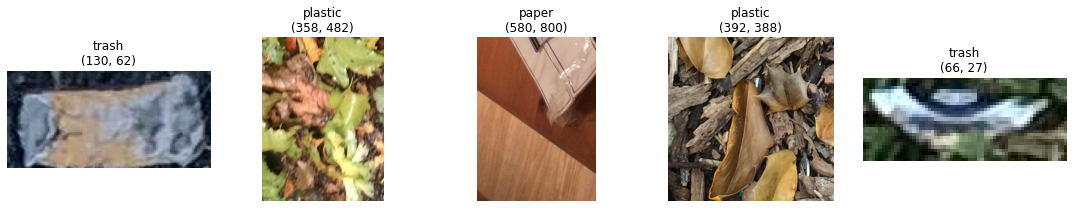

In [43]:
# ============================================================================
# DIAGNOSTIC: Why is TACO training failing to converge?
# ============================================================================
print("Total TACO samples:", len(taco_df))
print("\nClass distribution:")
print(taco_df['class_name'].value_counts())
print("\nClass distribution (%):")
print((taco_df['class_name'].value_counts(normalize=True) * 100).round(1))

# Check how severe the imbalance actually is
counts = taco_df['class_name'].value_counts()
print(f"\nMost common class: {counts.idxmax()} ({counts.max()} samples)")
print(f"Least common class: {counts.idxmin()} ({counts.min()} samples)")
print(f"Imbalance ratio: {counts.max() / counts.min():.1f}x")

# Check bbox crop sizes — TACO's small-target objects might be producing tiny/degenerate crops
import random as rnd
sample_rows = taco_df.sample(min(20, len(taco_df)), random_state=1)
crop_sizes = []
for _, row in sample_rows.iterrows():
    if row['bbox'] is not None:
        _, _, w, h = row['bbox']
        crop_sizes.append((w, h))
print(f"\nSample bbox crop sizes (w, h) in original pixels:")
for w, h in crop_sizes[:20]:
    print(f"  {w:.0f} x {h:.0f}")

widths = [w for w, h in crop_sizes]
heights = [h for w, h in crop_sizes]
print(f"\nMedian crop width: {np.median(widths):.0f}px, height: {np.median(heights):.0f}px")
print(f"Min crop width: {min(widths):.0f}px, height: {min(heights):.0f}px")

# Visualize a few actual crops to see what the model is being trained on
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (_, row) in enumerate(sample_rows.head(5).iterrows()):
    img = Image.open(row['path']).convert('RGB')
    if row['bbox'] is not None:
        x, y, w, h = row['bbox']
        img_w, img_h = img.size
        x0, y0 = max(0, int(x)), max(0, int(y))
        x1, y1 = min(img_w, int(x + w)), min(img_h, int(y + h))
        crop = img.crop((x0, y0, x1, y1))
    else:
        crop = img
    axes[i].imshow(crop)
    axes[i].set_title(f"{row['class_name']}\n{crop.size}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [73]:
# # ============================================================================
# # FIX 1: Filter out degenerate tiny crops before training
# # Objects smaller than a reasonable pixel threshold get upscaled into noise.
# # Paper's own small-target enhancement was a 10% bbox enlargement, not a fix
# # for genuinely tiny boxes like 31x13 — those need to either be dropped or
# # use the full image as context instead of a near-empty crop.
# # ============================================================================
# MIN_CROP_DIM = 40  # pixels — boxes smaller than this in either dimension are unreliable

# def filter_degenerate_boxes(df, min_dim=MIN_CROP_DIM):
#     def is_valid(bbox):
#         if bbox is None:
#             return True  # no bbox (e.g. TrashNet) — always valid
#         _, _, w, h = bbox
#         return w >= min_dim and h >= min_dim

#     mask = df['bbox'].apply(is_valid)
#     dropped = (~mask).sum()
#     print(f"Dropping {dropped} samples with crop dimension < {min_dim}px "
#           f"({dropped/len(df)*100:.1f}% of dataset)")
#     return df[mask].reset_index(drop=True)

# taco_df_filtered = filter_degenerate_boxes(taco_df)
# print("\nTACO samples after filtering tiny crops:", len(taco_df_filtered))
# print(taco_df_filtered['class_name'].value_counts())

In [55]:
# ============================================================================
# STRICTER FILTER: Raise minimum ORIGINAL box size (not just "broken" boxes).
# The visual check showed that boxes under ~50-80px often have no visually
# distinctive object even after context-padding — the object blends into its
# background at that native resolution, so no crop strategy fixes it.
# This drops more samples than before, but keeps only ones a model has a
# real chance of learning from.
# ============================================================================
MIN_ORIGINAL_BOX_SIDE = 70  # pixels, in ORIGINAL image coordinates (not padded crop size)

def filter_by_original_box_size(df, min_side=MIN_ORIGINAL_BOX_SIDE):
    def is_valid(bbox):
        if bbox is None:
            return True  # TrashNet — no bbox, always keep
        _, _, w, h = bbox
        return w >= min_side and h >= min_side

    mask = df['bbox'].apply(is_valid)
    dropped = (~mask).sum()
    print(f"Dropping {dropped} samples with original box side < {min_side}px "
          f"({dropped/len(df)*100:.1f}% of dataset)")
    return df[mask].reset_index(drop=True)

taco_df_strict = filter_by_original_box_size(taco_df_filtered, min_side=MIN_ORIGINAL_BOX_SIDE)
print("\nTACO samples after stricter size filtering:", len(taco_df_strict))
print(taco_df_strict['class_name'].value_counts())
print("\nClass distribution (%):")
print((taco_df_strict['class_name'].value_counts(normalize=True) * 100).round(1))

Dropping 1018 samples with original box side < 70px (27.4% of dataset)

TACO samples after stricter size filtering: 2693
class_name
plastic      1530
metal         394
trash         261
paper         198
cardboard     178
glass         132
Name: count, dtype: int64

Class distribution (%):
class_name
plastic      56.8
metal        14.6
trash         9.7
paper         7.4
cardboard     6.6
glass         4.9
Name: proportion, dtype: float64


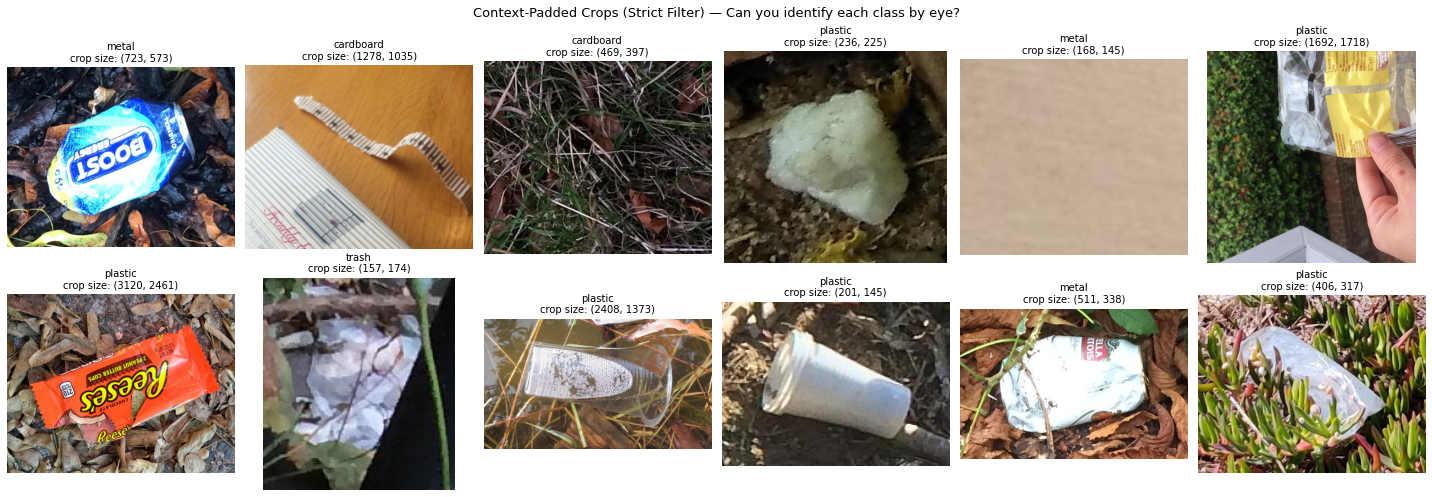


Labels shown above, in order:
  1. metal (original bbox: [2030.5, 969.4, 517.0, 409.2])
  2. cardboard (original bbox: [480.7, 258.4, 1106.6, 739.2])
  3. cardboard (original bbox: [1733.8, 865.1, 334.4, 283.8])
  4. plastic (original bbox: [630.35, 2538.7, 168.3, 160.6])
  5. metal (original bbox: [1765.55, 1366.3, 119.9, 103.4])
  6. plastic (original bbox: [793.05, 1042.1, 1208.9, 1559.8])
  7. plastic (original bbox: [181.1, 984.1, 2879.8, 1757.8])
  8. trash (original bbox: [2797.9, 110.35, 112.2, 124.3])
  9. plastic (original bbox: [477.85, 2023.4, 1719.3, 981.2])
  10. plastic (original bbox: [2306.4999999999995, 1156.3, 143.0, 103.39999999999975])
  11. metal (original bbox: [1444.4, 945.05, 365.2, 240.9])
  12. plastic (original bbox: [743.85, 2348.7, 289.3, 226.6])


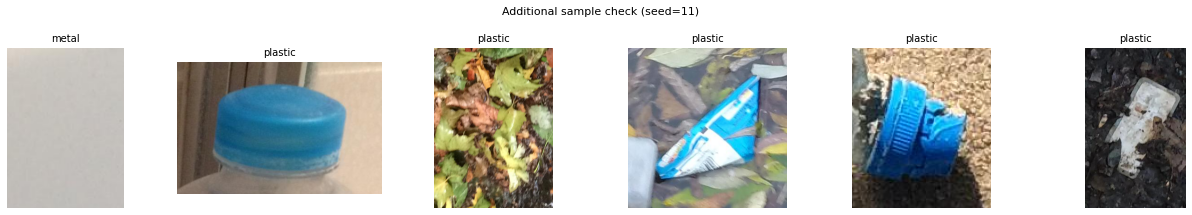

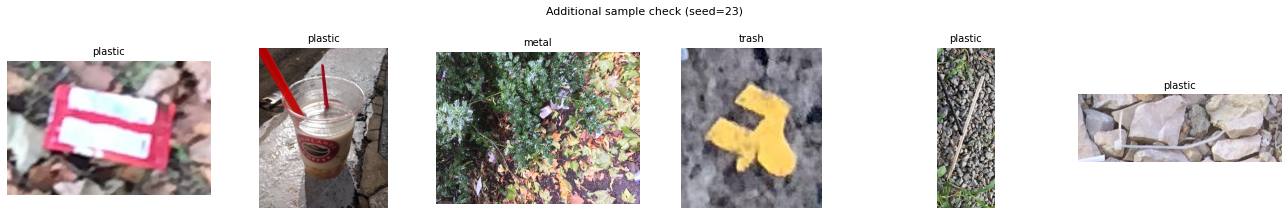

In [56]:
# ============================================================================
# RE-CHECK: Same visual sanity check, but now on the strictly-filtered set.
# Every crop shown here should be reasonably identifiable by eye.
# ============================================================================
sample_rows = taco_df_strict.sample(12, random_state=7)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row['path']).convert('RGB')
    if row['bbox'] is not None:
        crop = get_context_padded_crop(img, row['bbox'])
    else:
        crop = img
    axes[i].imshow(crop)
    axes[i].set_title(f"{row['class_name']}\ncrop size: {crop.size}", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Context-Padded Crops (Strict Filter) — Can you identify each class by eye?", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "taco_strictfilter_sanity_check.png", dpi=120)
plt.show()

print("\nLabels shown above, in order:")
for i, (_, row) in enumerate(sample_rows.iterrows()):
    print(f"  {i+1}. {row['class_name']} (original bbox: {row['bbox']})")

# Try a couple more random samples too, to get broader confidence before training
for seed in [11, 23]:
    sample_rows2 = taco_df_strict.sample(6, random_state=seed)
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    for i, (_, row) in enumerate(sample_rows2.iterrows()):
        img = Image.open(row['path']).convert('RGB')
        crop = get_context_padded_crop(img, row['bbox']) if row['bbox'] is not None else img
        axes[i].imshow(crop)
        axes[i].set_title(f"{row['class_name']}", fontsize=10)
        axes[i].axis('off')
    plt.suptitle(f"Additional sample check (seed={seed})", fontsize=11)
    plt.tight_layout()
    plt.show()

In [72]:
# ============================================================================
# FIX 2: Sqrt-dampened class weights (unchanged from before)
# ============================================================================
def compute_class_weights_sqrt(labels, num_classes):
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    counts[counts == 0] = 1.0
    weights = np.sqrt(counts.sum() / (num_classes * counts))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


# ============================================================================
# FIX 3 (UPDATED): Context-padded crop instead of full-image.
# Full images caused train_acc to plateau flat around 50-53% for 170+ epochs —
# the object got lost in cluttered scenes. Context-padded crops (verified by
# eye in the sanity check) keep the object visible while giving the CNN real
# texture, instead of either a blurry raw-tiny crop or a diluted full scene.
# Sqrt weights and patience=25 are kept from before.
# ============================================================================
MIN_CROP_SIDE = 120
PAD_RATIO = 0.4

def get_context_padded_crop(img, bbox, min_side=MIN_CROP_SIDE, pad_ratio=PAD_RATIO):
    img_w, img_h = img.size
    x, y, w, h = bbox
    cx, cy = x + w / 2, y + h / 2
    new_w = max(w * (1 + pad_ratio), min_side)
    new_h = max(h * (1 + pad_ratio), min_side)
    x0 = max(0, int(cx - new_w / 2))
    y0 = max(0, int(cy - new_h / 2))
    x1 = min(img_w, int(cx + new_w / 2))
    y1 = min(img_h, int(cy + new_h / 2))
    if x1 <= x0 or y1 <= y0:
        return img
    return img.crop((x0, y0, x1, y1))


class WasteDatasetContextCrop(Dataset):
    def __init__(self, df, transform=None, use_context_crop=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.use_context_crop = use_context_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.use_context_crop and row['source'] == 'taco' and row['bbox'] is not None:
            img = get_context_padded_crop(img, row['bbox'])
        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])


def train_ressemo_paperspec_taco(model, train_loader, val_loader, class_weights, total_epochs=200,
                                   switch_epoch=None, patience=25, log_prefix="ressemo"):
    """Same as train_ressemo_paperspec but with higher patience for TACO."""
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)
    scheduler = None
    history = {'train_acc': [], 'train_f1': [], 'val_acc': [], 'val_f1': [], 'train_loss': [], 'val_loss': []}
    best_val_f1, best_state, epochs_no_improve, switched = 0.0, None, 0, False
    switch_epoch = switch_epoch or (total_epochs // 4)

    for epoch in range(1, total_epochs + 1):
        if not switched and epoch >= switch_epoch:
            optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=0.0005)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, total_epochs - epoch))
            switched = True
            print(f"[Epoch {epoch}] Switched optimizer: Adam -> SGD + CosineAnnealing")

        train_loss, train_acc, train_f1 = train_one_epoch_paperspec(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate_paperspec(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()

        for k, v in [('train_loss', train_loss), ('train_acc', train_acc), ('train_f1', train_f1),
                     ('val_loss', val_loss), ('val_acc', val_acc), ('val_f1', val_f1)]:
            history[k].append(v)

        print(f"[{log_prefix}] Epoch {epoch}/{total_epochs} "
              f"train_acc={train_acc:.4f} train_f1={train_f1:.4f} "
              f"val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

        # Track by F1, not accuracy — accuracy is misleading under this much imbalance
        if val_f1 > best_val_f1:
            best_val_f1, best_state, epochs_no_improve = val_f1, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def run_single_fold_taco_fixed(df, dataset_name, fold, train_idx, val_idx, epochs, patience=25):
    paths = fold_paths(dataset_name, fold)
    if fold_already_done(dataset_name, fold):
        print(f"[SKIP] {dataset_name} fold {fold} already completed.")
        with open(paths['metrics']) as f:
            return json.load(f)

    print(f"\n===== {dataset_name} Fold {fold}/{N_SPLITS} "
          f"(context-padded crop, min_side={MIN_CROP_SIDE}, sqrt weights, patience={patience}) =====")
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    # CHANGED: WasteDatasetContextCrop with use_context_crop=True,
    # instead of WasteDataset with crop_bbox=False (full-image, previous attempt)
    train_ds = WasteDatasetContextCrop(train_df, transform=train_transform, use_context_crop=True)
    val_ds = WasteDatasetContextCrop(val_df, transform=eval_transform, use_context_crop=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    class_weights = compute_class_weights_sqrt(train_df['label'].values, NUM_CLASSES)
    print("Class weights (sqrt-dampened):", class_weights.numpy())

    model = ResSeMo(num_classes=NUM_CLASSES).to(DEVICE)
    model, history = train_ressemo_paperspec_taco(model, train_loader, val_loader, class_weights,
                                                     total_epochs=epochs, patience=patience,
                                                     log_prefix=f"{dataset_name}-fold{fold}")

    _, val_acc, val_f1, y_true, y_pred = evaluate_paperspec(model, val_loader)
    metrics = {'fold': fold, 'val_acc': float(val_acc), 'val_f1': float(val_f1)}

    torch.save(model.state_dict(), paths['model'])
    with open(paths['history'], 'w') as f: json.dump(history, f)
    with open(paths['metrics'], 'w') as f: json.dump(metrics, f)
    print(f"[SAVED] {dataset_name} fold {fold}: acc={val_acc:.4f} f1={val_f1:.4f}")

    model = model.to('cpu')
    del model, train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache(); torch.cuda.synchronize()
    return metrics


def run_kfold_cv_taco_fixed(df, dataset_name, n_splits=N_SPLITS, epochs=TOTAL_EPOCHS, patience=25):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    labels = df['label'].values
    return [run_single_fold_taco_fixed(df, dataset_name, fold, tr, va, epochs, patience)
            for fold, (tr, va) in enumerate(skf.split(df, labels), start=1)]


# ---- Run using the STRICTLY-filtered dataset (taco_df_strict), with a NEW
# dataset_name so results save separately from your earlier "taco_fixed" run ----
_ = run_kfold_cv_taco_fixed(taco_df_strict, "taco_contextcrop_strict", n_splits=N_SPLITS, epochs=TOTAL_EPOCHS, patience=25)
taco_cv_results, taco_cv_summary = aggregate_cv_results_paperspec("taco_contextcrop_strict", n_splits=N_SPLITS)


===== taco_contextcrop_strict Fold 1/5 (context-padded crop, min_side=120, sqrt weights, patience=25) =====
Class weights (sqrt-dampened): [1.209409   1.4113885  0.81486547 1.1505691  0.41338098 1.0003871 ]
[taco_contextcrop_strict-fold1] Epoch 1/200 train_acc=0.5292 train_f1=0.1392 val_acc=0.5677 val_f1=0.1207
[taco_contextcrop_strict-fold1] Epoch 2/200 train_acc=0.5580 train_f1=0.1359 val_acc=0.5659 val_f1=0.1205
[taco_contextcrop_strict-fold1] Epoch 3/200 train_acc=0.5566 train_f1=0.1227 val_acc=0.4991 val_f1=0.1217
[taco_contextcrop_strict-fold1] Epoch 4/200 train_acc=0.5594 train_f1=0.1239 val_acc=0.5677 val_f1=0.1207
[taco_contextcrop_strict-fold1] Epoch 5/200 train_acc=0.5613 train_f1=0.1220 val_acc=0.5677 val_f1=0.1207
[taco_contextcrop_strict-fold1] Epoch 6/200 train_acc=0.5645 train_f1=0.1203 val_acc=0.5677 val_f1=0.1207
[taco_contextcrop_strict-fold1] Epoch 7/200 train_acc=0.5673 train_f1=0.1208 val_acc=0.5659 val_f1=0.1205
[taco_contextcrop_strict-fold1] Epoch 8/200 train_